<a href="https://colab.research.google.com/github/Israamanaziz/16S-rRNA_QIIME2_workflow_using_Colab.ipynb/blob/main/16S_rRNA_QIIME2_workflow_using_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Step 1: Install Miniforge

In [ ]:
!wget -qO Miniforge3.sh https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh
!bash ./Miniforge3.sh -b -f -p /usr/local

###Step 2: Install Qiime2 in its own env
This can take around 10-20 mins

In [ ]:
!wget https://raw.githubusercontent.com/qiime2/distributions/refs/heads/dev/2026.1/amplicon/released/qiime2-amplicon-ubuntu-latest-conda.yml
!/usr/local/bin/mamba env create -n qiime2 --file qiime2-amplicon-ubuntu-latest-conda.yml

####Step 3:Make Qiime executabke in the notebook

In [3]:
import os
os.environ['PATH'] = f"/usr/local/envs/qiime2/bin:{os.environ['PATH']}"

In [ ]:
# check qiime version
!qiime info

###step 4: Download materials from ISB Microbiome 2024

In [5]:
!git clone https://github.com/gibbons-lab/isb_course_2024 materials
%cd materials

Cloning into 'materials'...
remote: Enumerating objects: 1106, done.
remote: Counting objects: 100% (272/272), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 1106 (delta 216), reused 156 (delta 130), pack-reused 834 (from 1)
Receiving objects: 100% (1106/1106), 203.07 MiB | 29.61 MiB/s, done.
Resolving deltas: 100% (498/498), done.
Updating files: 100% (622/622), done.
/content/materials


#### Import Dependencies and view the data using pandas

In [6]:
import pandas as pd
manifest = pd.read_csv('data/manifest.tsv', sep = '\t')
manifest

,sample-id,absolute-filepath
0,ERR1513701,$PWD/data/ERR1513701.fastq.gz
1,ERR1513870,$PWD/data/ERR1513870.fastq.gz
2,ERR1513889,$PWD/data/ERR1513889.fastq.gz
3,ERR1513684,$PWD/data/ERR1513684.fastq.gz
4,ERR1513703,$PWD/data/ERR1513703.fastq.gz
5,ERR1514003,$PWD/data/ERR1514003.fastq.gz
6,ERR1513961,$PWD/data/ERR1513961.fastq.gz
7,ERR1513983,$PWD/data/ERR1513983.fastq.gz
8,ERR1513964,$PWD/data/ERR1513964.fastq.gz
9,ERR1513777,$PWD/data/ERR1513777.fastq.gz


In [7]:
metadata = pd.read_csv('data/metadata.tsv', sep='\t')
metadata

,id,parkinson_disease,sex,age,bmi,stool_travel_time,location,anticholinergic,carbidopa_levodopa,comt_inhibitor,p3m_antibiotics_bool,p3m_constipation,fruits_or_vegetables,grains
0,ERR1513684,Yes,male,58.0,25.33,6.0,"Atlanta, GA",N,Y,N,Yes,Yes,At least once a day,At least once a day
1,ERR1513701,Yes,male,78.0,18.99,2.0,"Atlanta, GA",N,Y,N,No,No,Few times a week,At least once a day
2,ERR1513703,Yes,female,53.0,27.92,4.0,"Atlanta, GA",N,Y,N,Yes,No,At least once a day,At least once a day
3,ERR1513777,No,female,62.0,22.96,1.0,"Albany, NY",N,N,N,No,No,At least once a day,At least once a day
4,ERR1513870,Yes,male,70.0,25.68,8.0,"Seattle, WA",N,Y,N,Yes,Yes,Few times a week,At least once a day
5,ERR1513889,Yes,male,78.0,30.51,3.0,"Seattle, WA",N,Y,N,No,No,At least once a day,Few times a week
6,ERR1513961,No,female,67.0,24.48,2.0,"Seattle, WA",N,N,N,Yes,No,At least once a day,At least once a day
7,ERR1513964,No,female,69.0,33.47,4.0,"Seattle, WA",N,N,N,No,No,At least once a day,Few times a week
8,ERR1513983,No,female,72.0,25.84,2.0,"Seattle, WA",N,N,N,No,No,At least once a day,At least once a day
9,ERR1514003,No,male,63.0,31.29,3.0,"Seattle, WA",N,N,N,No,No,At least once a day,At least once a day


In [8]:
# Import your reads into qza format
!qiime tools import \
  --type 'SampleData[SequencesWithQuality]' \
  --input-path data/manifest.tsv \
  --output-path sequences.qza \
  --input-format SingleEndFastqManifestPhred33V2

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Imported data/manifest.tsv as SingleEndFastqManifestPhred33V2 to sequences.qza


In [9]:
# Check your read quality
!qiime demux summarize \
--i-data sequences.qza \
--o-visualization qualities.qzv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: qualities.qzv


In [10]:
# Remove or denoise the reads using dada2 and create feature table
!qiime dada2 denoise-single \
  --i-demultiplexed-seqs sequences.qza \
  --p-trunc-len 150 \  # the trunc length can be changed as per the user
  --p-n-threads 2 \
  --output-dir dada --verbose

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Running external command line application(s). This may print messages to stdout and/or stderr.
The command(s) being run are below. These commands cannot be manually re-run as they will depend on temporary files that no longer exist.

Command: run_dada.R --input_directory /tmp/qiime2/root/data/6e1d0794-83de-48bb-95f7-10b5600c7b3f/data --output_path /tmp/tmp4qy6lw21/output.tsv.biom --output_track /tmp/tmp4qy6lw21/track.tsv --output_err_track /tmp/tmp4qy6lw21/err_track.tsv --filtered_directory /tmp/tmp4qy6lw21 --truncation_length 150 --trim_left 0 --max_expected_errors 2.0 --truncation_quality_score 2 --max_length Inf --pooling_method independent --chimer

In [11]:
#TO view the dada2 stats, download fie in qzv and view in qiime2view
!qiime metadata tabulate \
  --m-input-file dada/denoising_stats.qza \
  --o-visualization dada/denoising_stats.qzv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: dada/denoising_stats.qzv


### Creating a phylogenetic tree

In [12]:
!qiime phylogeny align-to-tree-mafft-fasttree \
    --i-sequences dada/representative_sequences.qza \
    --output-dir tree

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[AlignedSequence] to: tree/alignment.qza
Saved FeatureData[AlignedSequence] to: tree/masked_alignment.qza
Saved Phylogeny[Unrooted] to: tree/tree.qza
Saved Phylogeny[Rooted] to: tree/rooted_tree.qza


### Diversity metrics Alpha (within samples) and Beta (between samples)

In [13]:
!qiime diversity core-metrics-phylogenetic \
    --i-table dada/table.qza \
    --i-phylogeny tree/rooted_tree.qza \
    --p-sampling-depth 5000 \
    --m-metadata-file data/metadata.tsv \
    --output-dir diversity

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: diversity/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: diversity/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: diversity/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: diversity/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: diversity/evenness_vector.qza
Saved DistanceMatrix to: diversity/unweighted_unifrac_distance_matrix.qza
Saved DistanceMatrix to: diversity/weighted_unifrac_distance_matrix.qza
Saved DistanceMatrix to: diversity/jaccard_distance_matrix.qza
Saved DistanceMatrix to: diversity/bray_curtis_distance_matrix.qza
Saved PCoAResults to: diversity/unweighted_un

In [14]:
!qiime diversity adonis \
    --i-distance-matrix diversity/weighted_unifrac_distance_matrix.qza \
    --m-metadata-file data/metadata.tsv \
    --p-formula "parkinson_disease" \
    --p-n-jobs 2 \
    --o-visualization diversity/permanova.qzv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: diversity/permanova.qzv


In [18]:
# checking scikit learn version
!python -c "import sklearn; print(sklearn.__version__)"

1.4.2


In [19]:
#Downloading a pre-trained Naive Bayes taxonomic classifier file (.qza) trained on the Greengenes database (version 13.8)
#specifically for the 515F/806R region of the 16S rRNA gene. This was used due to version conflict with the old refseq classifier used in ISB 2024
!wget -O "gg-13-8-99-515-806-nb-classifier.qza" \
  https://data.qiime2.org/classifiers/sklearn-1.4.2/greengenes/gg-13-8-99-515-806-nb-classifier.qza

--2026-10-09 18:03:37--  https://data.qiime2.org/classifiers/sklearn-1.4.2/greengenes/gg-13-8-99-515-806-nb-classifier.qza
Resolving data.qiime2.org (data.qiime2.org)... 54.200.1.12
Connecting to data.qiime2.org (data.qiime2.org)|54.200.1.12|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://s3-us-west-2.amazonaws.com/qiime2-data/classifiers/sklearn-1.4.2/greengenes/gg-13-8-99-515-806-nb-classifier.qza [following]
--2026-10-09 18:03:38--  https://s3-us-west-2.amazonaws.com/qiime2-data/classifiers/sklearn-1.4.2/greengenes/gg-13-8-99-515-806-nb-classifier.qza
Resolving s3-us-west-2.amazonaws.com (s3-us-west-2.amazonaws.com)... 52.92.153.232, 52.218.180.248, 52.92.229.32, ...
Connecting to s3-us-west-2.amazonaws.com (s3-us-west-2.amazonaws.com)|52.92.153.232|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2334033 (2.2M) [binary/octet-stream]
Saving to: ‘gg-13-8-99-515-806-nb-classifier.qza’

gg-13-8-99-515-806- 100%[===========

In [20]:
#Assigning taxonomy to sequences

!qiime feature-classifier classify-sklearn \
  --i-reads dada/representative_sequences.qza \
  --i-classifier /content/materials/gg-13-8-99-515-806-nb-classifier.qza \
  --p-n-jobs 2 \
  --o-classification taxonomy.qza \
  --verbose

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[Taxonomy] to: taxonomy.qza


In [21]:
#Converting the binary taxonomy artifact into an interactive, human-readable file (taxonomy.qzv) so we can view taxonomy assignments in QIIME2 View
!qiime metadata tabulate \
  --m-input-file taxonomy.qza \
  --o-visualization taxonomy.qzv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: taxonomy.qzv


In [23]:
# generating an interactibe taxa plot
!qiime taxa barplot \
    --i-table dada/table.qza \
    --i-taxonomy taxonomy.qza \
    --m-metadata-file data/metadata.tsv \
    --o-visualization taxa_barplot.qzv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: taxa_barplot.qzv


In [24]:
# collapsing data to genus level and saved as genus.qza
!qiime taxa collapse \
    --i-table dada/table.qza \
    --i-taxonomy taxonomy.qza \
    --p-level 6 \
    --o-collapsed-table genus.qza

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: genus.qza


In [26]:
!qiime feature-table heatmap \
  --i-table genus.qza \
  --m-sample-metadata-file data/metadata.tsv \
  --m-sample-metadata-column parkinson_disease \
  --o-visualization genus_heatmap.qzv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: genus_heatmap.qzv


#### To create a publication style heatmap, one can convert qza to tsv

In [27]:
!qiime tools export \
    --input-path genus.qza \
    --output-path exported

!biom convert -i exported/feature-table.biom -o genus.tsv --to-tsv

/usr/local/envs/qiime2/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported genus.qza as BIOMV210DirFmt to directory exported


In [28]:
abundances = pd.read_table("genus.tsv", skiprows=1, index_col=0)
abundances

,ERR1513684,ERR1513701,ERR1513703,ERR1513777,ERR1513870,ERR1513889,ERR1513961,ERR1513964,ERR1513983,ERR1514003
#OTU ID,,,,,,,,,,
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,2299.0,3242.0,2305.0,3994.0,5371.0,3939.0,2813.0,3127.0,398.0,2620.0
k__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacteriales;f__Enterobacteriaceae;g__Klebsiella,1351.0,0.0,8500.0,0.0,0.0,0.0,0.0,0.0,291.0,386.0
k__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacteriales;f__Enterobacteriaceae;g__Escherichia,1210.0,562.0,1435.0,28.0,0.0,37.0,9.0,1784.0,37.0,2109.0
k__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pseudomonadales;f__Moraxellaceae;g__Acinetobacter,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,99.0,4585.0
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium,847.0,0.0,186.0,2482.0,3995.0,1000.0,1025.0,1113.0,344.0,698.0
...,...,...,...,...,...,...,...,...,...,...
k__Bacteria;p__Actinobacteria;__;__;__;__,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Dermabacteraceae;g__Brachybacterium,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
k__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rickettsiales;f__mitochondria;g__Lardizabala,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0


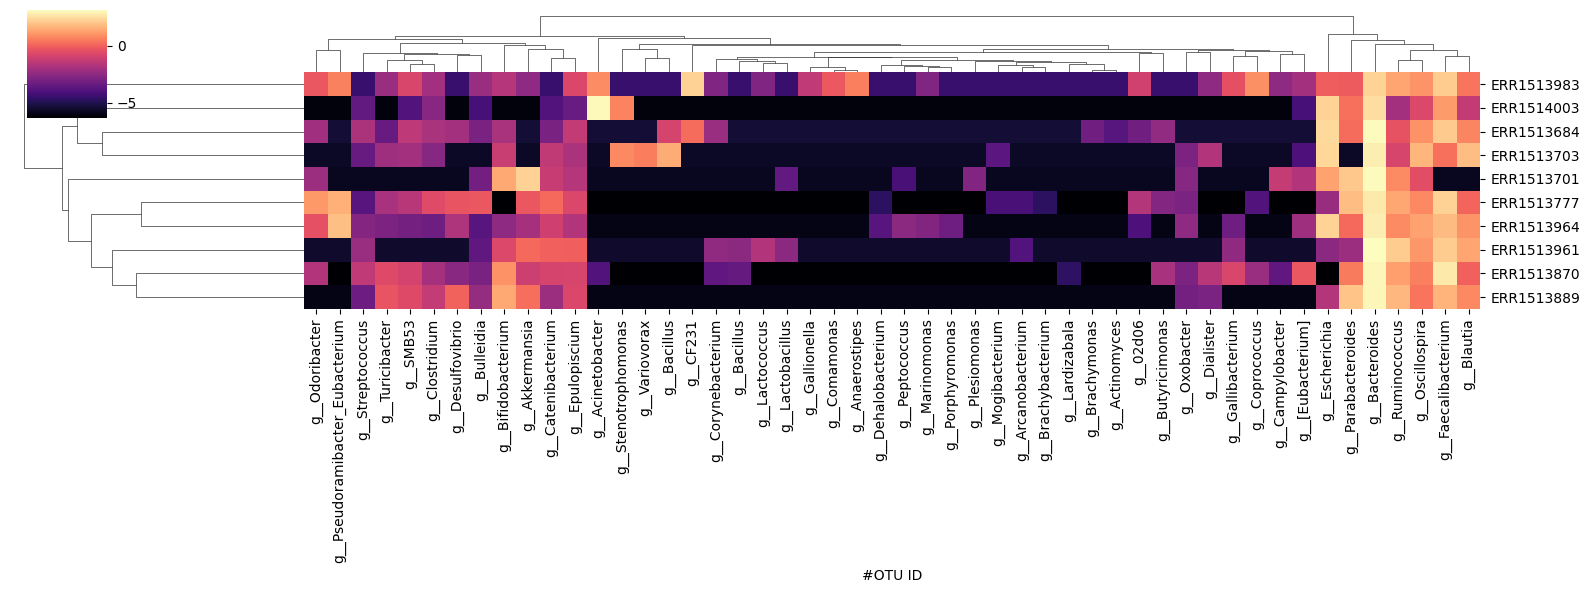

In [29]:
import numpy as np
import seaborn as sns

abund_to_plot = abundances.copy()
abund_to_plot.index = abund_to_plot.index.str.split(";").str[5]          # Use only the genus name
abund_to_plot = abund_to_plot[~abund_to_plot.index.isin(["g__", "__"])]  # remove unclassified genera
abund_to_plot = abund_to_plot.sample(50, axis=0)                         # use 50 random genera (rows)

# Let's do a centered log-ratio transform: log x_i - log mean(x)
transformed = abund_to_plot.apply(
    lambda xs: np.log(xs + 0.5) - np.log(xs.mean() + 0.5),
    axis=0)

sns.clustermap(transformed.T, cmap="magma", xticklabels=True, figsize=(16, 6))